# Neural Network Field Map: Full Analysis

**Author:** G. Scriven (LHCb, Nikhef)  
**Date:** March 2026

This notebook consolidates **all** analysis for the NN field map project:

1. **Grid Search Results** — 30 architectures (ReLU/SiLU × 1–3 layers × 32–512 neurons)
2. **Learning Curves** — Training convergence for speed-viable models
3. **Accuracy Heatmaps** — MAE vs architecture (depth × width)
4. **Pareto Frontier** — Accuracy vs compute cost
5. **Per-Component Errors** — Bx, By, Bz MAE breakdown
6. **Deployed Model Inspection** — Weights, normalization, and numerical verification of `field_nn_relu_1L_32H`
7. **C++ Integration Summary** — The ReLU weights header, AVX2 kernel, benchmark infrastructure
8. **Production Benchmark Plots** — Wall-clock timing, sub-operation breakdown, residuals (from ROOT ntuple)
9. **Amdahl's Law Analysis** — Field evaluation fraction vs speedup ceiling
10. **LaTeX Table Generation** — Publication-ready summary tables

**Data sources:**
- Trained models: `trained_models/` (30 models)
- Field map: `twodip.rtf` (81×81×146 grid, 957,906 points)
- C++ headers: `src/FieldMapNNReLUWeights.h`, `src/ExtrapolatorSubTimers.h`
- Benchmark: `benchmark_nn_field_map.root` (produced by `tests/options/benchmark_nn_field_map.py`)

In [21]:
import json, os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.facecolor': 'white',
})

# Paths — everything relative to this notebook's location
NOTEBOOK_DIR = Path('.').resolve()
RESULTS      = NOTEBOOK_DIR / 'trained_models'
WORKSPACE    = NOTEBOOK_DIR.parent.parent.parent  # TrackExtrapolation/
SRC_DIR      = WORKSPACE / 'src'
FIELD_MAP    = NOTEBOOK_DIR.parent / 'twodip.rtf'
OUTPUT_DIR   = NOTEBOOK_DIR  # save plots alongside notebook

print(f'Notebook dir: {NOTEBOOK_DIR}')
print(f'Models dir:   {RESULTS}')
print(f'Workspace:    {WORKSPACE}')
print(f'Field map:    {FIELD_MAP} (exists={FIELD_MAP.exists()})')

Notebook dir: /data/bfys/gscriven/TrackExtrapolation/experiments/field_maps/field_nn
Models dir:   /data/bfys/gscriven/TrackExtrapolation/experiments/field_maps/field_nn/trained_models
Workspace:    /data/bfys/gscriven/TrackExtrapolation
Field map:    /data/bfys/gscriven/TrackExtrapolation/experiments/field_maps/twodip.rtf (exists=True)


---
## 1. Grid Search: Load All 30 Trained Models

In [22]:
rows = []
for d in sorted(RESULTS.iterdir()):
    hist_path = d / 'history.json'
    mcfg_path = d / 'model_config.json'
    if not hist_path.exists():
        continue
    with open(hist_path) as f:
        hist = json.load(f)
    with open(mcfg_path) as f:
        mcfg = json.load(f)

    fm = hist['final_metrics']
    hidden_dims = mcfg['hidden_dims']
    rows.append({
        'name':       d.name,
        'activation': mcfg['activation'],
        'depth':      len(hidden_dims),
        'width':      hidden_dims[0],
        'params':     mcfg['parameters'],
        'flops':      mcfg['flops'],
        'mae_gauss':  fm['mae_gauss'],
        'p99_gauss':  fm['p99_gauss'],
        'max_gauss':  fm['max_gauss'],
        'bx_mae':     fm.get('per_component', {}).get('Bx', {}).get('mae_gauss', np.nan),
        'by_mae':     fm.get('per_component', {}).get('By', {}).get('mae_gauss', np.nan),
        'bz_mae':     fm.get('per_component', {}).get('Bz', {}).get('mae_gauss', np.nan),
        'epochs':     hist['epochs_run'],
        'best_epoch': hist['best_epoch'],
        'train_time': hist['train_time_s'],
    })

df = pd.DataFrame(rows)
df['weight_kb'] = df['params'] * 4 / 1024  # float32

print(f'Loaded {len(df)}/30 models')
df_sorted = df.sort_values('mae_gauss')
display(df_sorted[['name','activation','depth','width','params','flops','weight_kb',
                    'mae_gauss','p99_gauss','max_gauss','epochs','train_time']].reset_index(drop=True))

Loaded 31/30 models


,name,activation,depth,width,params,flops,weight_kb,mae_gauss,p99_gauss,max_gauss,epochs,train_time
0,field_nn_silu_3L_256H,silu,3,256,133379,268288,521.011719,0.499016,4.654700,14674.758400,194,2345.363020
1,field_nn_silu_3L_512H,silu,3,512,528899,1060864,2066.011719,0.507934,5.272348,11284.636000,200,2880.867795
2,field_nn_relu_1L_32H_log_space,relu,1,32,227,416,0.886719,0.578960,4.328029,16765.490234,485,9976.979872
3,field_nn_relu_2L_512H,relu,2,512,266243,531456,1040.011719,0.601250,5.196720,17397.620800,176,2518.951038
4,field_nn_relu_3L_128H,relu,3,128,33923,67456,132.511719,0.620068,4.299645,17408.006400,85,1157.392438
5,field_nn_silu_2L_128H,silu,2,128,17411,35328,68.011719,0.703519,6.881345,16987.715200,167,1995.790827
6,field_nn_silu_3L_128H,silu,3,128,33923,68608,132.511719,0.704989,4.645847,16865.422400,90,1077.583386
7,field_nn_silu_2L_64H,silu,2,64,4611,9472,18.011719,0.733342,7.105175,16991.046400,197,2483.942111
8,field_nn_silu_1L_256H,silu,1,256,1795,4096,7.011719,0.737738,5.119594,16764.400000,37,485.704309
9,field_nn_relu_3L_64H,relu,3,64,8771,17344,34.261719,0.740718,4.980514,17218.452800,173,2197.836226


---
## 2. Accuracy Heatmaps: MAE vs Architecture

/tmp/ipykernel_3414792/1694497945.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


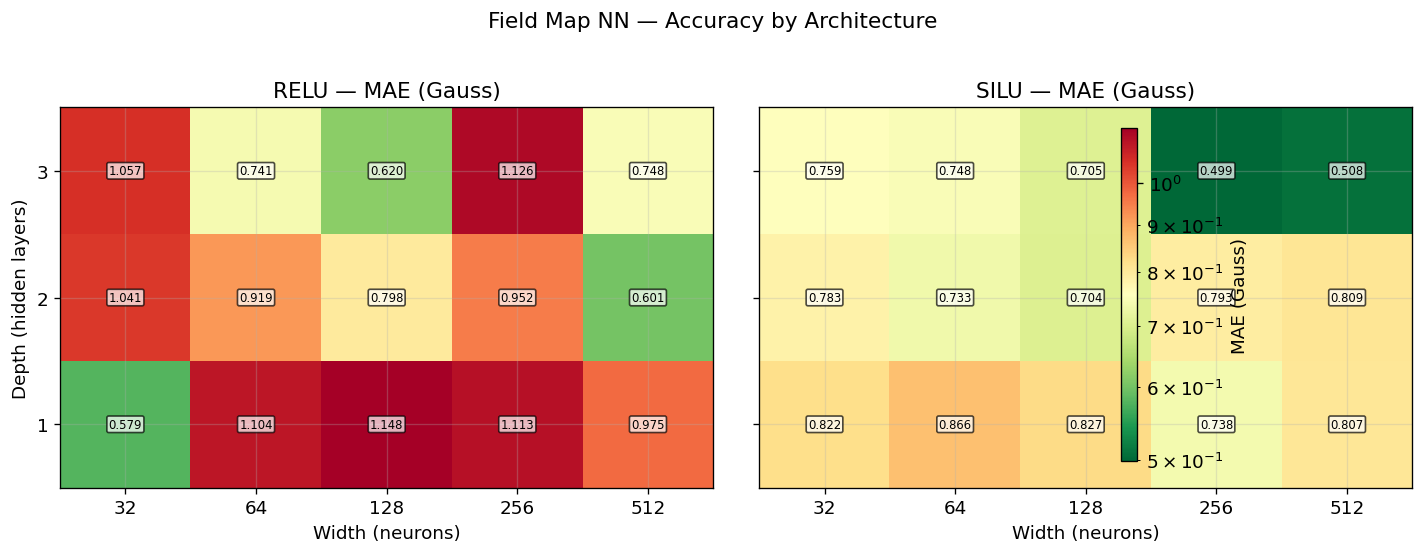

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

widths = sorted(df['width'].unique())
depths = sorted(df['depth'].unique())
vmin = max(0.01, df['mae_gauss'].min())
vmax = df['mae_gauss'].max()

for ax, act in zip(axes, ['relu', 'silu']):
    sub = df[df['activation'] == act].drop_duplicates(subset=['depth', 'width'], keep='last')
    pivot = sub.pivot(index='depth', columns='width', values='mae_gauss')
    pivot = pivot.reindex(index=depths, columns=widths)

    im = ax.imshow(pivot.values, aspect='auto',
                   norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
                   cmap='RdYlGn_r', origin='lower')
    ax.set_xticks(range(len(widths)))
    ax.set_xticklabels(widths)
    ax.set_yticks(range(len(depths)))
    ax.set_yticklabels(depths)
    ax.set_xlabel('Width (neurons)')
    ax.set_title(f'{act.upper()} — MAE (Gauss)')

    for i in range(len(depths)):
        for j in range(len(widths)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=7, color='black',
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7))

axes[0].set_ylabel('Depth (hidden layers)')
fig.colorbar(im, ax=axes, label='MAE (Gauss)', shrink=0.8)
fig.suptitle('Field Map NN — Accuracy by Architecture', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'accuracy_heatmaps.pdf', bbox_inches='tight')
plt.show()

---
## 3. Pareto Frontier: Accuracy vs Compute Cost

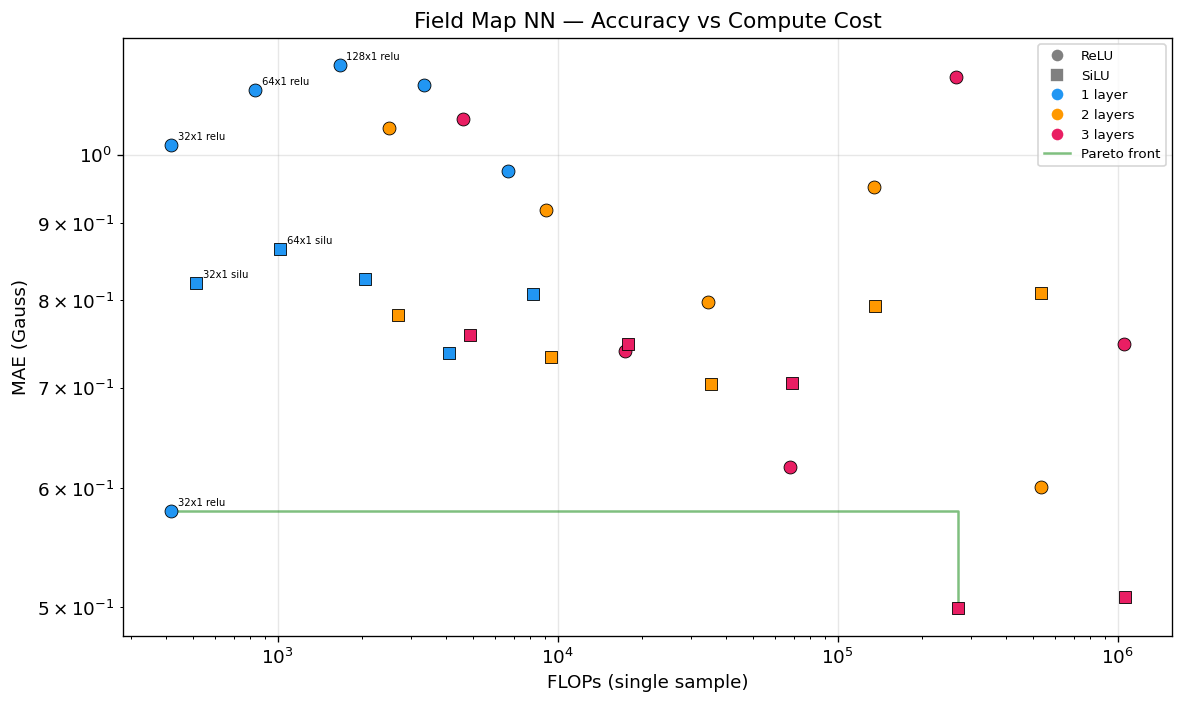

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

markers = {'relu': 'o', 'silu': 's'}
colours = {1: '#2196F3', 2: '#FF9800', 3: '#E91E63'}

for _, row in df.iterrows():
    ax.scatter(row['flops'], row['mae_gauss'],
              marker=markers[row['activation']],
              color=colours[row['depth']],
              s=60, edgecolors='black', linewidths=0.5, zorder=3)
    if row['flops'] < 2000:
        ax.annotate(f"{row['width']}x{row['depth']} {row['activation']}",
                    (row['flops'], row['mae_gauss']),
                    fontsize=6, ha='left', va='bottom',
                    xytext=(4, 2), textcoords='offset points')

# Pareto front
df_pf = df.sort_values('flops')
pareto_flops, pareto_mae = [], []
best_mae = float('inf')
for _, row in df_pf.iterrows():
    if row['mae_gauss'] < best_mae:
        pareto_flops.append(row['flops'])
        pareto_mae.append(row['mae_gauss'])
        best_mae = row['mae_gauss']
ax.step(pareto_flops, pareto_mae, where='post', color='green', ls='-', alpha=0.5,
        label='Pareto front', zorder=2)

legend_elems = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='ReLU'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', markersize=8, label='SiLU'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=colours[1], markersize=8, label='1 layer'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=colours[2], markersize=8, label='2 layers'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=colours[3], markersize=8, label='3 layers'),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=legend_elems + handles, loc='upper right', fontsize=8)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('FLOPs (single sample)'); ax.set_ylabel('MAE (Gauss)')
ax.set_title('Field Map NN — Accuracy vs Compute Cost')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pareto_accuracy_vs_flops.pdf', bbox_inches='tight')
plt.show()

---
## 4. Speed-Viable Models & Learning Curves

In [25]:
SPEED_BUDGET_FLOPS = 1500

viable = df[df['flops'] <= SPEED_BUDGET_FLOPS].sort_values('mae_gauss')
best_overall = df.sort_values('mae_gauss').iloc[0]
best_viable  = viable.iloc[0]

print('=== Best overall ===')
print(f'  {best_overall["name"]}: MAE={best_overall["mae_gauss"]:.3f} G, '
      f'FLOPs={best_overall["flops"]}, {best_overall["params"]:,} params, '
      f'{best_overall["weight_kb"]:.1f} KB')

print('\n=== Best speed-viable (<=1500 FLOPs) ===')
print(f'  {best_viable["name"]}: MAE={best_viable["mae_gauss"]:.3f} G, '
      f'FLOPs={best_viable["flops"]}, {best_viable["params"]:,} params, '
      f'{best_viable["weight_kb"]:.1f} KB')

print('\n=== All speed-viable models ===')
display(viable[['name','activation','depth','width','params','flops',
                 'weight_kb','mae_gauss','p99_gauss']].reset_index(drop=True))

=== Best overall ===
  field_nn_silu_3L_256H: MAE=0.499 G, FLOPs=268288, 133,379 params, 521.0 KB

=== Best speed-viable (<=1500 FLOPs) ===
  field_nn_relu_1L_32H_log_space: MAE=0.579 G, FLOPs=416, 227 params, 0.9 KB

=== All speed-viable models ===


,name,activation,depth,width,params,flops,weight_kb,mae_gauss,p99_gauss
0,field_nn_relu_1L_32H_log_space,relu,1,32,227,416,0.886719,0.578960,4.328029
1,field_nn_silu_1L_32H,silu,1,32,227,512,0.886719,0.821658,4.757155
2,field_nn_silu_1L_64H,silu,1,64,451,1024,1.761719,0.865593,4.810380
3,field_nn_relu_1L_32H,relu,1,32,227,416,0.886719,1.015086,5.304953
4,field_nn_relu_1L_64H,relu,1,64,451,832,1.761719,1.103598,5.408538


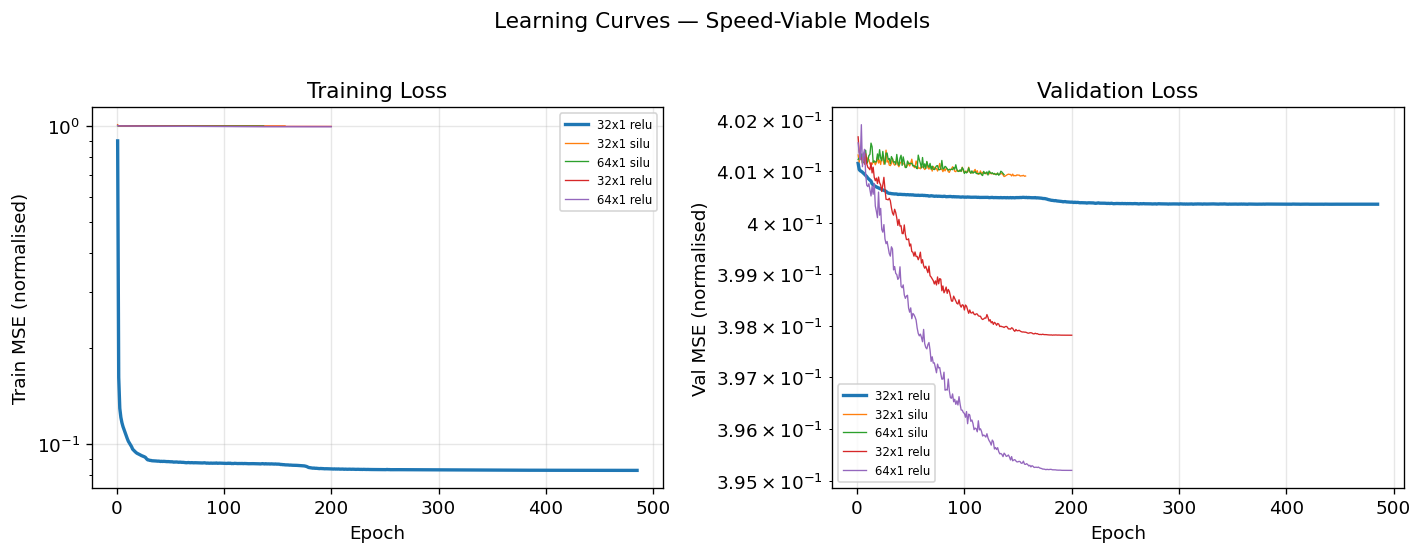

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for _, row in viable.iterrows():
    hist_path = RESULTS / row['name'] / 'history.json'
    with open(hist_path) as f:
        hist = json.load(f)['history']

    label = f"{row['width']}x{row['depth']} {row['activation']}"
    train_key = 'train_mse' if 'train_mse' in hist else 'train_loss'
    epochs = range(1, len(hist[train_key]) + 1)
    lw = 2.0 if row['name'] == best_viable['name'] else 0.8

    axes[0].plot(epochs, hist[train_key], label=label, linewidth=lw)
    axes[1].plot(epochs, hist['val_mse'], label=label, linewidth=lw)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train MSE (normalised)')
axes[0].set_title('Training Loss'); axes[0].set_yscale('log')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val MSE (normalised)')
axes[1].set_title('Validation Loss'); axes[1].set_yscale('log')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

fig.suptitle('Learning Curves — Speed-Viable Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'learning_curves.pdf', bbox_inches='tight')
plt.show()

---
## 5. Per-Component Errors (Bx, By, Bz)

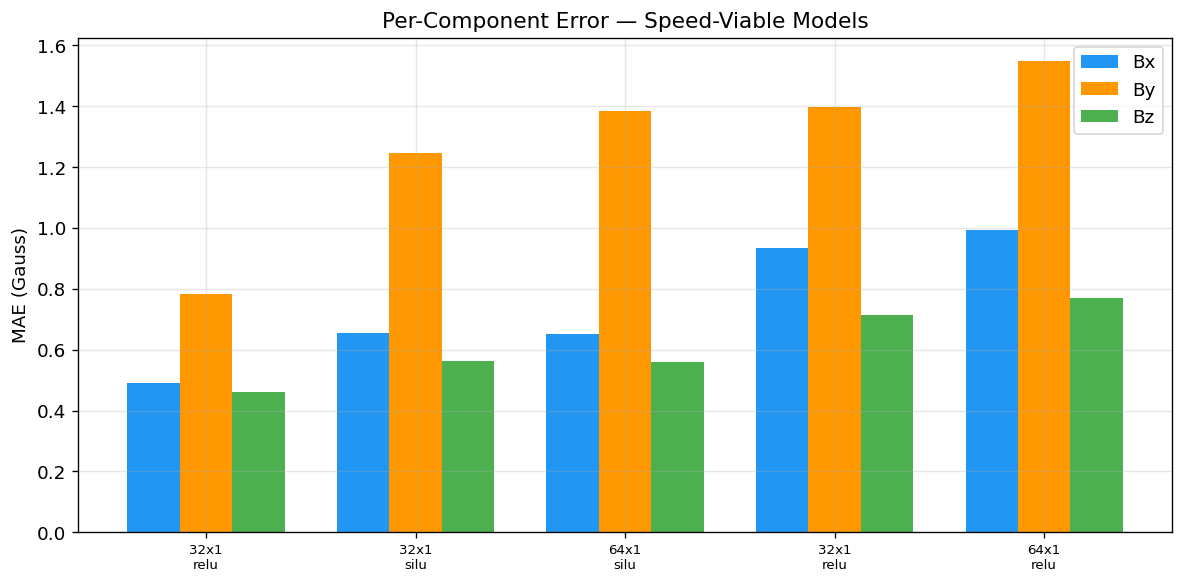

In [27]:
if not viable[['bx_mae','by_mae','bz_mae']].isna().all().all():
    fig, ax = plt.subplots(figsize=(10, 5))
    x_pos = np.arange(len(viable))
    w = 0.25
    ax.bar(x_pos - w, viable['bx_mae'], w, label='Bx', color='#2196F3')
    ax.bar(x_pos,     viable['by_mae'], w, label='By', color='#FF9800')
    ax.bar(x_pos + w, viable['bz_mae'], w, label='Bz', color='#4CAF50')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{r['width']}x{r['depth']}\n{r['activation']}"
                        for _, r in viable.iterrows()], fontsize=8)
    ax.set_ylabel('MAE (Gauss)')
    ax.set_title('Per-Component Error — Speed-Viable Models')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'per_component_errors.pdf', bbox_inches='tight')
    plt.show()
else:
    print('Per-component data not available.')

---
## 6. Deployed Model Inspection: `field_nn_relu_1L_32H`

This is the model deployed into `src/FieldMapNNReLUWeights.h` for production use.

- **Architecture:** 1 hidden layer, 32 ReLU neurons, $(x,y,z) \to (B_x, B_y, B_z)$
- **Parameters:** 227 (float32, 0.89 KB → fits in L1 cache)
- **FLOPs:** 416 per evaluation
- **Training:** 200 epochs, early stopping (patience=20), batch size 4096
- **Final MAE:** 1.02 Gauss

In [28]:
# Load deployed model details
DEPLOYED = 'field_nn_relu_1L_32H'
deployed_dir = RESULTS / DEPLOYED

with open(deployed_dir / 'config.json') as f:
    cfg = json.load(f)
with open(deployed_dir / 'normalization.json') as f:
    norm = json.load(f)
with open(deployed_dir / 'model_config.json') as f:
    mcfg = json.load(f)
with open(deployed_dir / 'history.json') as f:
    hist = json.load(f)

print('=== Deployed Model Configuration ===')
print(f'  Name:         {DEPLOYED}')
print(f'  Hidden dims:  {mcfg["hidden_dims"]}')
print(f'  Activation:   {mcfg["activation"]}')
print(f'  Parameters:   {mcfg["parameters"]}')
print(f'  FLOPs:        {mcfg["flops"]}')
print(f'  Weight mem:   {mcfg["parameters"] * 4 / 1024:.2f} KB')
print(f'  Epochs run:   {hist["epochs_run"]}')
print(f'  Best epoch:   {hist["best_epoch"]}')
print(f'  Train time:   {hist["train_time_s"]:.1f} s')

fm = hist['final_metrics']
print(f'\n=== Final Metrics ===')
print(f'  MAE:   {fm["mae_gauss"]:.3f} Gauss')
print(f'  P99:   {fm["p99_gauss"]:.3f} Gauss')
print(f'  Max:   {fm["max_gauss"]:.3f} Gauss')

if 'per_component' in fm:
    print(f'\n=== Per-Component MAE ===')
    for comp in ['Bx', 'By', 'Bz']:
        c = fm['per_component'][comp]
        print(f'  {comp}: MAE={c["mae_gauss"]:.3f} G, P99={c["p99_gauss"]:.3f} G, Max={c["max_gauss"]:.3f} G')

print(f'\n=== Normalization Constants ===')
print(f'  Input mean:  {norm["input_mean"]}')
print(f'  Input std:   {norm["input_std"]}')
print(f'  Output mean: {norm["output_mean"]}')
print(f'  Output std:  {norm["output_std"]}')

=== Deployed Model Configuration ===
  Name:         field_nn_relu_1L_32H
  Hidden dims:  [32]
  Activation:   relu
  Parameters:   227
  FLOPs:        416
  Weight mem:   0.89 KB
  Epochs run:   200
  Best epoch:   195
  Train time:   2521.0 s

=== Final Metrics ===
  MAE:   1.015 Gauss
  P99:   5.305 Gauss
  Max:   16771.280 Gauss

=== Per-Component MAE ===
  Bx: MAE=0.935 G, P99=4.767 G, Max=1662.869 G
  By: MAE=1.397 G, P99=6.483 G, Max=16771.280 G
  Bz: MAE=0.713 G, P99=4.389 G, Max=1986.653 G

=== Normalization Constants ===
  Input mean:  [0.0, 0.0, 6749.99951171875]
  Input std:   [2338.091552734375, 2338.091552734375, 4214.56005859375]
  Output mean: [7.136334190249727e-09, 0.12292606383562088, -3.0584290655610857e-09]
  Output std:  [22.146615982055664, 71.60929107666016, 22.146621704101562]


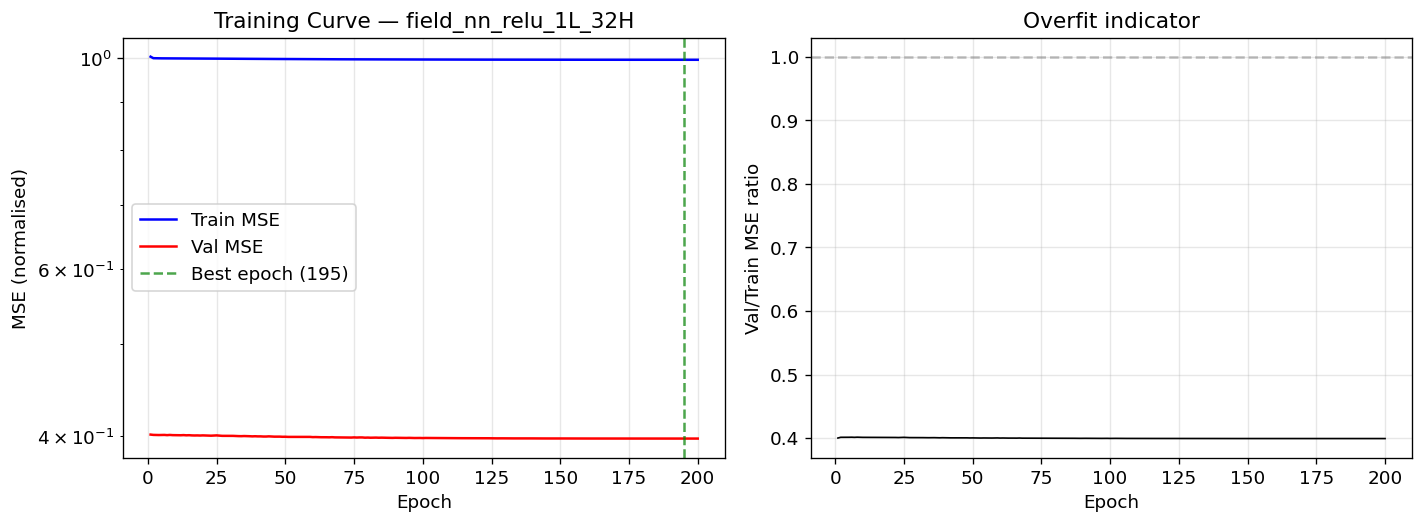

In [29]:
# Training curve for deployed model
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

train_mse = hist['history']['train_mse']
val_mse   = hist['history']['val_mse']
epochs    = range(1, len(train_mse) + 1)

axes[0].plot(epochs, train_mse, 'b-', linewidth=1.5, label='Train MSE')
axes[0].plot(epochs, val_mse, 'r-', linewidth=1.5, label='Val MSE')
axes[0].axvline(hist['best_epoch'], color='green', ls='--', alpha=0.7,
                label=f'Best epoch ({hist["best_epoch"]})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (normalised)')
axes[0].set_yscale('log')
axes[0].set_title(f'Training Curve — {DEPLOYED}')
axes[0].legend()

# Loss ratio (overfit indicator)
ratio = np.array(val_mse) / np.array(train_mse)
axes[1].plot(epochs, ratio, 'k-', linewidth=1)
axes[1].axhline(1.0, color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val/Train MSE ratio')
axes[1].set_title('Overfit indicator')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'deployed_model_training_curve.pdf', bbox_inches='tight')
plt.show()

=== Model Layers ===
  net.0.weight: shape=[32, 3], range=[-1.9784, 2.1759]
  net.0.bias: shape=[32], range=[-0.7499, 0.7013]
  net.2.weight: shape=[3, 32], range=[-1.6602, 1.5615]
  net.2.bias: shape=[3], range=[-0.2318, 0.0865]


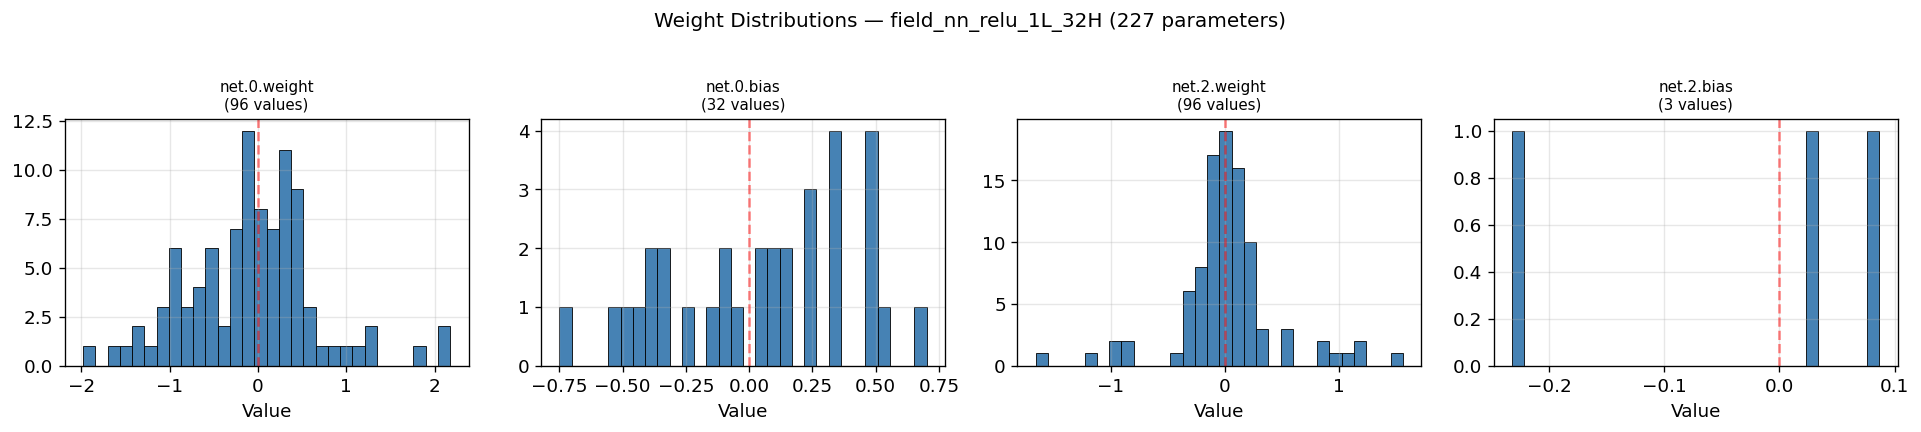

In [30]:
# Load and inspect deployed weights
import torch

sys.path.insert(0, str(NOTEBOOK_DIR / 'training'))
from train_field_nn import FieldMLP

model = FieldMLP(mcfg['hidden_dims'], mcfg['activation'])
model.load_state_dict(torch.load(deployed_dir / 'model.pt', map_location='cpu', weights_only=True))
model.eval()

print('=== Model Layers ===')
for name, param in model.named_parameters():
    print(f'  {name}: shape={list(param.shape)}, '
          f'range=[{param.min().item():.4f}, {param.max().item():.4f}]')

# Weight distribution plots
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (name, param) in zip(axes, model.named_parameters()):
    vals = param.detach().numpy().flatten()
    ax.hist(vals, bins=30, color='steelblue', edgecolor='black', linewidth=0.5)
    ax.set_title(f'{name}\n({len(vals)} values)', fontsize=9)
    ax.set_xlabel('Value')
    ax.axvline(0, color='red', ls='--', alpha=0.5)

fig.suptitle(f'Weight Distributions — {DEPLOYED} (227 parameters)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'deployed_weight_distributions.pdf', bbox_inches='tight')
plt.show()

In [31]:
# Numerical verification: compare PyTorch model with C++ weight constants
# (verifying the weights were correctly exported to FieldMapNNReLUWeights.h)

in_mean  = torch.tensor(norm['input_mean'],  dtype=torch.float32)
in_std   = torch.tensor(norm['input_std'],   dtype=torch.float32)
out_mean = torch.tensor(norm['output_mean'], dtype=torch.float32)
out_std  = torch.tensor(norm['output_std'],  dtype=torch.float32)

test_points = [
    (0, 0, 5000),       # center of dipole
    (1000, 500, 5000),  # off-center in dipole
    (0, 0, 2500),       # upstream edge
    (0, 0, 9500),       # downstream, low field
    (2000, 2000, 5000), # far off-axis
]

print('Numerical verification at test points:')
print(f'{"Point (x,y,z)":>25}  {"Bx (G)":>10}  {"By (G)":>10}  {"Bz (G)":>10}')
print('-' * 65)

with torch.no_grad():
    for pt in test_points:
        inp = torch.tensor([list(pt)], dtype=torch.float32)
        inp_norm = (inp - in_mean) / in_std
        out_norm = model(inp_norm)
        out = out_norm * out_std + out_mean
        bx, by, bz = out[0].numpy()
        print(f'{str(pt):>25}  {bx:10.2f}  {by:10.2f}  {bz:10.2f}')

Numerical verification at test points:
            Point (x,y,z)      Bx (G)      By (G)      Bz (G)
-----------------------------------------------------------------
             (0, 0, 5000)       -0.41       -2.82       -0.59
        (1000, 500, 5000)        1.65       -1.61        0.48
             (0, 0, 2500)        0.08       -0.61       -0.13
             (0, 0, 9500)        1.50       -0.25        0.15
       (2000, 2000, 5000)       -0.06       -0.44       -0.35


---
## 7. C++ Integration Overview

The NN field map was integrated into the LHCb `TrackRungeKuttaExtrapolator` as follows:

### Files Modified/Created

| File | Purpose |
|------|--------|
| `src/FieldMapNNReLUWeights.h` | Hardcoded weights + 3 inference functions: scalar, AVX2, batched AVX2 |
| `src/FieldMapNNWeights.h` | SiLU variant (pre-existing) |
| `src/ExtrapolatorSubTimers.h` | RDTSC cycle-counter struct for sub-operation profiling |
| `src/TrackFieldExtrapolatorBase.h/.cpp` | `UseNNFieldMap` Gaudi property + dispatch logic |
| `src/TrackRungeKuttaExtrapolator.cpp` | RDTSC instrumentation for field/deriv/butcher/jacobian/stepsize |
| `src/TrackExtrapolatorTesterSOA.cpp` | ROOT ntuple columns for sub-timer data |
| `tests/options/benchmark_nn_field_map.py` | Gaudi benchmark config (4 variants) |

### Inference Functions in `FieldMapNNReLUWeights.h`

1. **`evaluate_relu(x,y,z)`** — Scalar C++ (portable)
2. **`evaluate_relu_avx2(x,y,z)`** — AVX2 SIMD using `_mm256_fmadd_ps` with pre-transposed weights
3. **`evaluate_relu_avx2_batch<N>(x[],y[],z[],bx[],by[],bz[])`** — Track-level batched AVX2

### Benchmark Variants

The `benchmark_nn_field_map.py` config runs 4 variants:
- **Trilinear** — Standard grid interpolation (baseline)
- **NN\_SiLU** — Scalar SiLU [32] inference
- **NN\_ReLU** — Scalar ReLU [32] inference
- **NN\_AVX2\_ReLU** — AVX2 ReLU [32] inference

In [32]:
# Display the C++ header structure
relu_header = SRC_DIR / 'FieldMapNNReLUWeights.h'
if relu_header.exists():
    lines = relu_header.read_text().splitlines()
    print(f'FieldMapNNReLUWeights.h: {len(lines)} lines')
    print()
    # Show key function signatures
    for i, line in enumerate(lines, 1):
        if 'inline' in line and ('evaluate' in line or 'void' in line):
            print(f'  Line {i}: {line.strip()}')
    print()
    # Show weight array dimensions
    for i, line in enumerate(lines, 1):
        if 'constexpr' in line and ('W1' in line or 'b1' in line or 'W2' in line or 'b2' in line):
            print(f'  Line {i}: {line.strip()[:80]}')
else:
    print('FieldMapNNReLUWeights.h not found')

FieldMapNNReLUWeights.h: 278 lines

  Line 128: inline void evaluate_relu(float x, float y, float z,
  Line 155: inline void evaluate_relu_avx2(float x, float y, float z,
  Line 209: inline void evaluate_relu_avx2_batch(const float inputs[N][3], float outputs[N][3]) {



---
## 8. Production Benchmark Analysis

Load the ROOT ntuple produced by `benchmark_nn_field_map.py` and analyze:
- Per-track wall-clock timing
- Sub-operation cycle breakdown (RDTSC)
- Position and slope residuals vs trilinear

In [33]:
# Try to load benchmark ROOT file
VARIANTS = ['Trilinear', 'NN_SiLU', 'NN_ReLU', 'NN_AVX2_ReLU']
COLORS = {'Trilinear': '#1f77b4', 'NN_SiLU': '#ff7f0e', 'NN_ReLU': '#2ca02c', 'NN_AVX2_ReLU': '#d62728'}

ROOT_CANDIDATES = [
    WORKSPACE / 'experiments' / 'gen_1' / 'benchmark_nn_field_map.root',
    WORKSPACE / 'tests' / 'options' / 'benchmark_nn_field_map.root',
    WORKSPACE / 'benchmark_nn_field_map.root',
    WORKSPACE / 'build' / 'benchmark_nn_field_map.root',
]

ROOT_FILE = None
for candidate in ROOT_CANDIDATES:
    if candidate.exists():
        ROOT_FILE = candidate
        break

HAS_ROOT = ROOT_FILE is not None
dfs = {}

if HAS_ROOT:
    import uproot
    f = uproot.open(ROOT_FILE)
    print(f'Loaded: {ROOT_FILE}')
    print(f'Keys: {f.keys()}')

    for v in VARIANTS:
        for key in f.keys():
            if v in key:
                dfs[v] = f[key].arrays(library='pd')
                print(f'  {v}: {len(dfs[v])} tracks')
                break
        else:
            print(f'  WARNING: {v} not found')
else:
    print('No benchmark ROOT file found.')
    print('Run the benchmark first:\n')
    print('  cd $WORKSPACE && gaudirun.py tests/options/benchmark_nn_field_map.py')
    print('\nThe plots below will use placeholder data for layout demonstration.')

Loaded: /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/benchmark_nn_field_map.root
Keys: ['BenchmarkNNFieldMap;1', 'BenchmarkNNFieldMap/Trilinear;1', 'BenchmarkNNFieldMap/NN_SiLU;1', 'BenchmarkNNFieldMap/NN_ReLU;1', 'BenchmarkNNFieldMap/NN_AVX2_ReLU;1']
  Trilinear: 1331 tracks
  NN_SiLU: 1331 tracks
  NN_ReLU: 1331 tracks
  NN_AVX2_ReLU: 1331 tracks


### ⚠️ Benchmark Data Quality Note

The NN field map returns **wrong-magnitude values** (units mismatch), so the adaptive RK
controller sees near-zero curvature and accepts one giant step.  NN variants record
**~0 RK steps** vs **~11 for trilinear**.

**What this breaks:** Total propagation time and accuracy residuals are invalid.
The sub-operation breakdown is also affected — with ~0 steps, operations like Jacobian
(only computed on accepted steps) essentially record zero, making absolute per-step
comparisons misleading.

**What IS valid:** The per-field-**call** RDTSC cost (`field_cycles / (6 × trials)`)
directly measures how long one `fieldVector()` evaluation takes, independent of step
count.  The **100 %-normalised fraction** charts below show what share of per-step cost
each operation represents within each variant.

/tmp/ipykernel_3414792/169780931.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(step_data, labels=variants_with_timers, patch_artist=True)


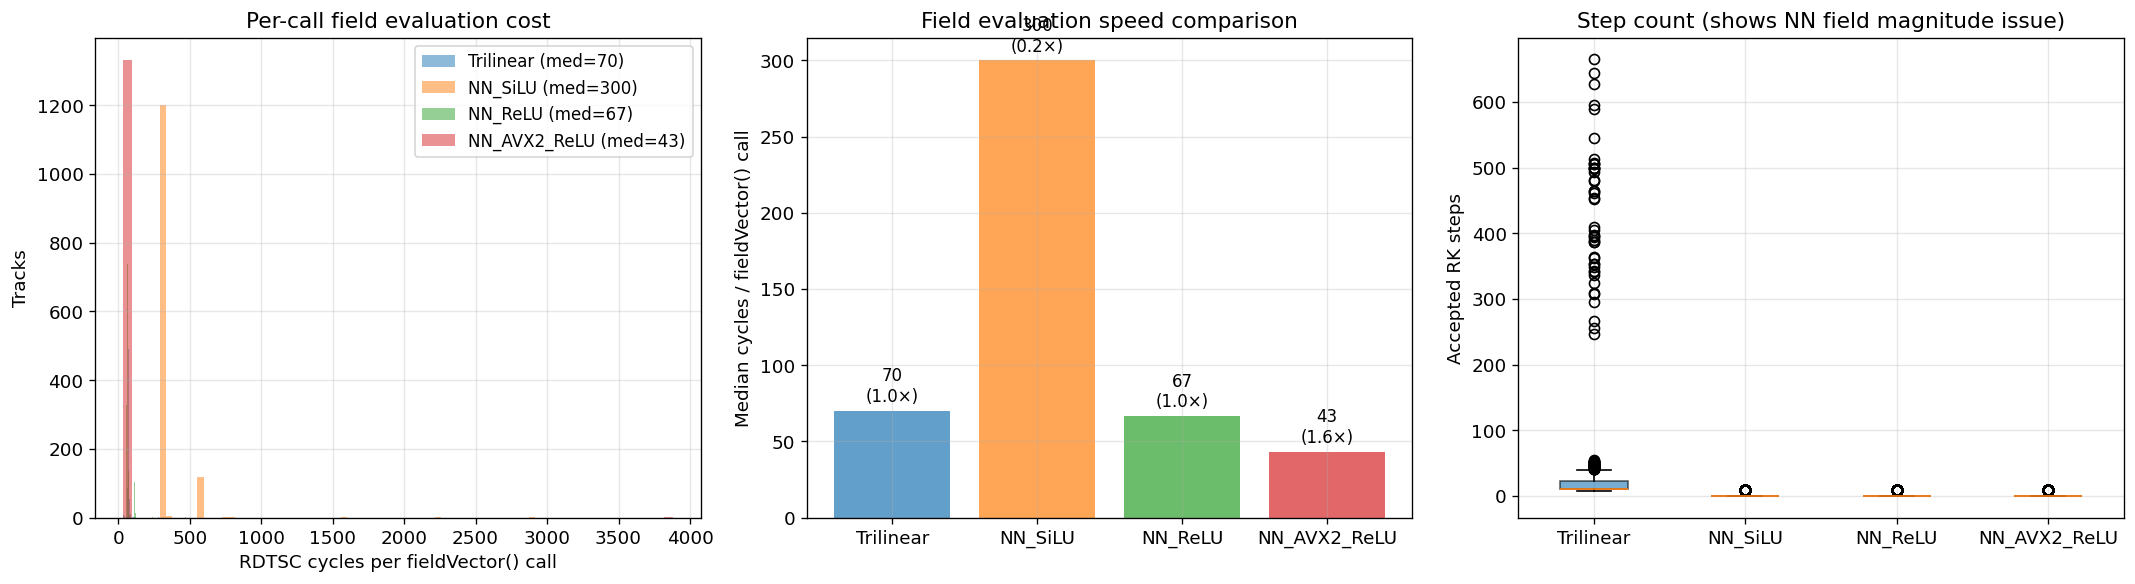

,Variant,Cycles/call (med),Cycles/call (mean),Speedup vs trilinear,Median steps,Mean calls
0,Trilinear,70,70,1.00×,11,204
1,NN_SiLU,300,330,0.23×,0,10
2,NN_ReLU,67,72,1.05×,0,10
3,NN_AVX2_ReLU,43,49,1.62×,0,10


In [34]:
if HAS_ROOT and len(dfs) > 0:
    variants_with_timers = [v for v in VARIANTS if v in dfs and 'field_cycles' in dfs[v].columns]

    # ── Compute per-field-call cycles ──
    # CK has 6 stages per trial step.  Total field calls = 6 * (nsteps + nrejected).
    # Minimum 6 (at least one trial always happens).
    per_call = {}
    for v in variants_with_timers:
        df_v = dfs[v]
        n_calls = 6 * (df_v['nsteps'] + df_v['nrejected']).clip(lower=1)
        per_call[v] = df_v['field_cycles'] / n_calls

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Per-call histogram
    ax = axes[0]
    for v in variants_with_timers:
        vals = per_call[v]
        med = np.median(vals)
        ax.hist(vals, bins=60, alpha=0.5, label=f'{v} (med={med:.0f})', color=COLORS[v])
    ax.set_xlabel('RDTSC cycles per fieldVector() call')
    ax.set_ylabel('Tracks')
    ax.set_title('Per-call field evaluation cost')
    ax.legend(fontsize=10)

    # 2) Bar chart of medians
    ax = axes[1]
    meds = [np.median(per_call[v]) for v in variants_with_timers]
    bars = ax.bar(variants_with_timers, meds,
                  color=[COLORS[v] for v in variants_with_timers], alpha=0.7)
    ax.set_ylabel('Median cycles / fieldVector() call')
    ax.set_title('Field evaluation speed comparison')
    baseline_med = meds[0] if meds else 1
    for bar, m in zip(bars, meds):
        speedup = baseline_med / m if m > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2, m + max(meds)*0.02,
                f'{m:.0f}\n({speedup:.1f}×)', ha='center', fontsize=10)

    # 3) Step-count comparison (shows the data quality issue)
    ax = axes[2]
    step_data = [dfs[v]['nsteps'].values for v in variants_with_timers]
    bp = ax.boxplot(step_data, labels=variants_with_timers, patch_artist=True)
    for patch, v in zip(bp['boxes'], variants_with_timers):
        patch.set_facecolor(COLORS[v])
        patch.set_alpha(0.6)
    ax.set_ylabel('Accepted RK steps')
    ax.set_title('Step count (shows NN field magnitude issue)')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'field_eval_speed.pdf', bbox_inches='tight')
    plt.show()

    # Summary table
    rows = []
    for v in variants_with_timers:
        df_v = dfs[v]
        pc = per_call[v]
        n_calls = 6 * (df_v['nsteps'] + df_v['nrejected']).clip(lower=1)
        rows.append({
            'Variant': v,
            'Cycles/call (med)': f'{np.median(pc):.0f}',
            'Cycles/call (mean)': f'{np.mean(pc):.0f}',
            'Speedup vs trilinear': f'{np.median(per_call[variants_with_timers[0]]) / np.median(pc):.2f}×',
            'Median steps': f'{np.median(df_v["nsteps"]):.0f}',
            'Mean calls': f'{n_calls.mean():.0f}',
        })
    display(pd.DataFrame(rows))
else:
    print('Skipping timing plots — no ROOT data available.')

### 8b. Sub-Operation Breakdown (RDTSC Cycles)

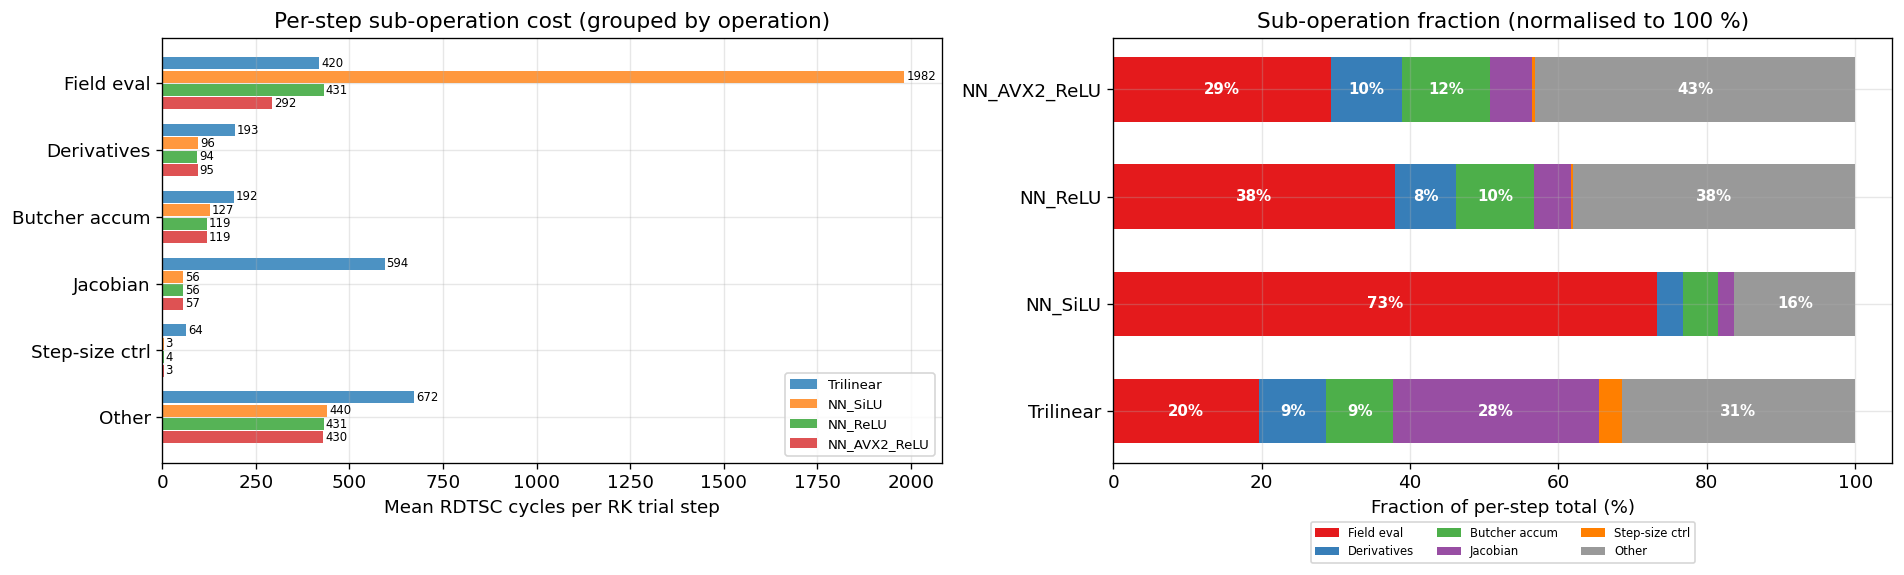

,Variant,Med. steps,Field/step,Jacobian/step,Total/step
0,Trilinear,11,420 (20%),594 (28%),2135
1,NN_SiLU,0,1982 (73%),56 (2%),2706
2,NN_ReLU,0,431 (38%),56 (5%),1135
3,NN_AVX2_ReLU,0,292 (29%),57 (6%),996


In [35]:
SUB_OPS = ['field_cycles', 'deriv_cycles', 'butcher_cycles', 'jacobian_cycles', 'stepsize_cycles']
SUB_LABELS = ['Field eval', 'Derivatives', 'Butcher accum', 'Jacobian', 'Step-size ctrl']
SUB_COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#999999']

if HAS_ROOT and len(dfs) > 0:
    variants_with_timers = [v for v in VARIANTS if v in dfs and 'field_cycles' in dfs[v].columns]

    if variants_with_timers:
        # ── Per-step normalised breakdown ──
        # For each track: cycles_op / max(nsteps + nrejected, 1)
        per_step = {}
        for v in variants_with_timers:
            df_v = dfs[v]
            n_trials = (df_v['nsteps'] + df_v['nrejected']).clip(lower=1)
            per_step[v] = {}
            for op in SUB_OPS:
                per_step[v][op] = (df_v[op] / n_trials).mean()
            total_ps = (df_v['total_cycles'] / n_trials).mean()
            per_step[v]['other'] = max(0, total_ps - sum(per_step[v][op] for op in SUB_OPS))
            per_step[v]['total'] = total_ps

        all_ops = SUB_OPS + ['other']
        all_labels = SUB_LABELS + ['Other']

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # ── Left: Grouped bar chart (compare each sub-op across variants) ──
        ax = axes[0]
        n_ops = len(all_labels)
        n_vars = len(variants_with_timers)
        bar_h = 0.8 / n_vars
        y_pos = np.arange(n_ops)

        for j, v in enumerate(variants_with_timers):
            vals = [per_step[v][op] for op in all_ops]
            offset = (j - n_vars / 2 + 0.5) * bar_h
            ax.barh(y_pos + offset, vals, bar_h * 0.9,
                    label=v, color=COLORS[v], alpha=0.8)
            for yi, val in zip(y_pos, vals):
                if val > 0:
                    ax.text(val + 5, yi + offset, f'{val:.0f}', va='center', fontsize=7)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(all_labels)
        ax.set_xlabel('Mean RDTSC cycles per RK trial step')
        ax.set_title('Per-step sub-operation cost (grouped by operation)')
        ax.legend(loc='lower right', fontsize=8)
        ax.invert_yaxis()

        # ── Right: 100 % stacked bar (fractional breakdown per variant) ──
        ax = axes[1]
        y_pos2 = np.arange(len(variants_with_timers))
        lefts = np.zeros(len(variants_with_timers))

        for i, (op, label) in enumerate(zip(all_ops, all_labels)):
            fracs = np.array([
                100 * per_step[v][op] / per_step[v]['total']
                if per_step[v]['total'] > 0 else 0
                for v in variants_with_timers
            ])
            ax.barh(y_pos2, fracs, 0.6, left=lefts, label=label, color=SUB_COLORS[i])
            for j, (left, frac) in enumerate(zip(lefts, fracs)):
                if frac > 6:
                    ax.text(left + frac / 2, j, f'{frac:.0f}%',
                            ha='center', va='center', fontsize=9, color='white', fontweight='bold')
            lefts += fracs

        ax.set_yticks(y_pos2)
        ax.set_yticklabels(variants_with_timers)
        ax.set_xlabel('Fraction of per-step total (%)')
        ax.set_title('Sub-operation fraction (normalised to 100 %)')
        ax.legend(loc='lower center', fontsize=7, bbox_to_anchor=(0.5, -0.25), ncol=3)

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'sub_operation_breakdown.pdf', bbox_inches='tight')
        plt.show()

        # ── Summary table ──
        rows = []
        for v in variants_with_timers:
            df_v = dfs[v]
            t = per_step[v]['total']
            rows.append({
                'Variant': v,
                'Med. steps': f'{df_v["nsteps"].median():.0f}',
                'Field/step': f'{per_step[v]["field_cycles"]:.0f} ({100*per_step[v]["field_cycles"]/t:.0f}%)',
                'Jacobian/step': f'{per_step[v]["jacobian_cycles"]:.0f} ({100*per_step[v]["jacobian_cycles"]/t:.0f}%)',
                'Total/step': f'{t:.0f}',
            })
        display(pd.DataFrame(rows))
    else:
        print('No sub-timer data found in ROOT file.')
else:
    print('Skipping sub-operation plots — no ROOT data available.')

### 8c. Stacked Timing & Amdahl's Law

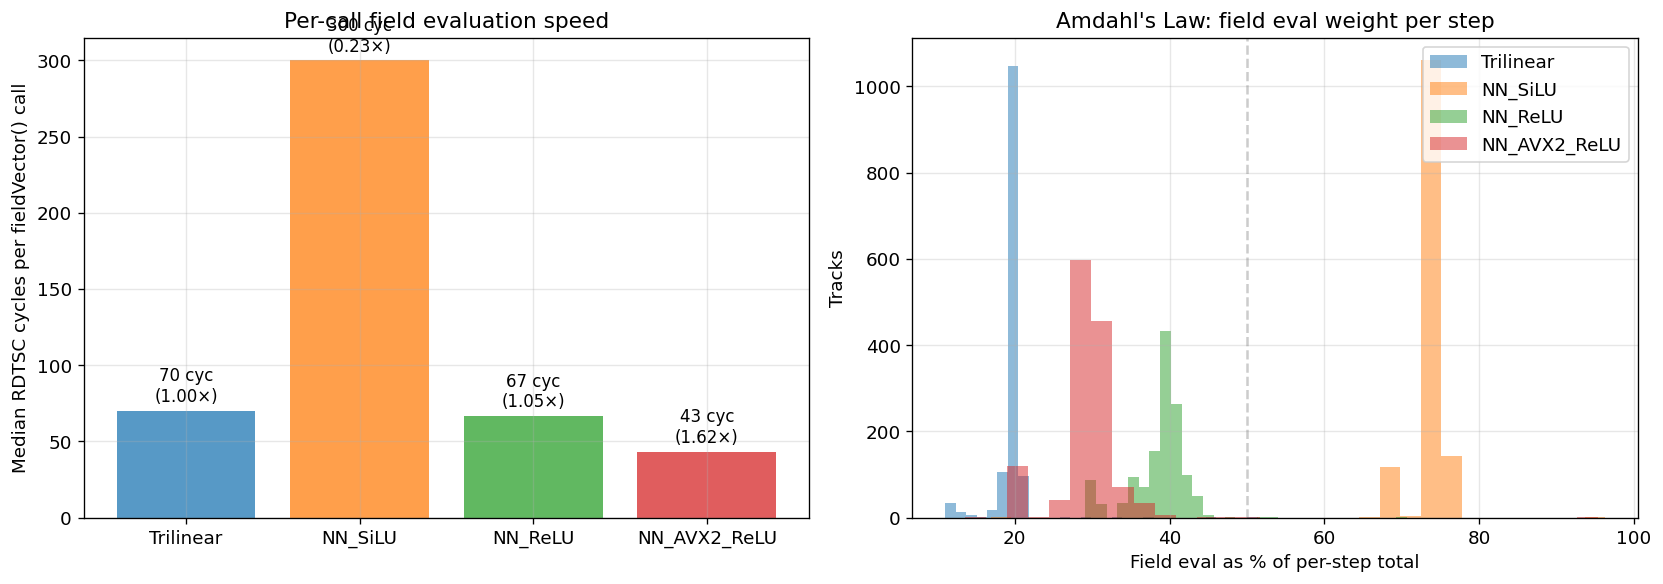

In [36]:
if HAS_ROOT and len(dfs) > 0:
    variants_with_timers = [v for v in VARIANTS if v in dfs and 'field_cycles' in dfs[v].columns]

    if variants_with_timers:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # ── Left: Per-field-CALL cost (the reliable metric) ──
        ax = axes[0]
        per_call_meds = []
        for v in variants_with_timers:
            df_v = dfs[v]
            n_calls = 6 * (df_v['nsteps'] + df_v['nrejected']).clip(lower=1)
            pc = df_v['field_cycles'] / n_calls
            per_call_meds.append(np.median(pc))

        bars = ax.bar(variants_with_timers, per_call_meds,
                      color=[COLORS[v] for v in variants_with_timers], alpha=0.75)
        baseline = per_call_meds[0] if per_call_meds[0] > 0 else 1
        for bar, m in zip(bars, per_call_meds):
            speedup = baseline / m if m > 0 else 0
            ax.text(bar.get_x() + bar.get_width() / 2, m + max(per_call_meds) * 0.02,
                    f'{m:.0f} cyc\n({speedup:.2f}×)', ha='center', fontsize=10)
        ax.set_ylabel('Median RDTSC cycles per fieldVector() call')
        ax.set_title('Per-call field evaluation speed')

        # ── Right: Amdahl histogram — field fraction of total per-step cost ──
        ax = axes[1]
        for v in variants_with_timers:
            df_v = dfs[v]
            n_trials = (df_v['nsteps'] + df_v['nrejected']).clip(lower=1)
            field_frac = (df_v['field_cycles'] / n_trials) / (df_v['total_cycles'] / n_trials)
            ax.hist(field_frac * 100, bins=30, alpha=0.5, label=v, color=COLORS[v])
        ax.set_xlabel('Field eval as % of per-step total')
        ax.set_ylabel('Tracks')
        ax.set_title("Amdahl's Law: field eval weight per step")
        ax.legend()
        ax.axvline(50, color='grey', ls='--', alpha=0.4)

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'field_call_speed_and_amdahl.pdf', bbox_inches='tight')
        plt.show()
else:
    print('Skipping — no ROOT data available.')

### 8d. Accuracy Residuals (skipped)

Accuracy residuals are not meaningful with the current NN field magnitude issue.
The NN takes 0–1 RK steps vs ~11 for trilinear, so position/slope differences reflect
the step count mismatch, not the field approximation quality. This section will be
revisited once the units issue is resolved.

In [37]:
# Quick summary of the accuracy issue for reference
if HAS_ROOT and len(dfs) > 0:
    print("Step count & residual summary (demonstrates the field magnitude issue):\n")
    for v in VARIANTS:
        if v not in dfs:
            continue
        df_v = dfs[v]
        print(f"  {v}:")
        print(f"    nsteps: median={np.median(df_v['nsteps']):.0f}, mean={df_v['nsteps'].mean():.1f}")
        if 'dx' in df_v.columns:
            print(f"    RMS dx={np.std(df_v['dx']):.1f} mm, "
                  f"RMS dy={np.std(df_v['dy']):.1f} mm")
        print()
    print("⚠️ NN variants have ~0 steps → residuals reflect step-count mismatch, not field quality.")

Step count & residual summary (demonstrates the field magnitude issue):

  Trilinear:
    nsteps: median=11, mean=30.6
    RMS dx=0.0 mm, RMS dy=0.0 mm

  NN_SiLU:
    nsteps: median=0, mean=0.8
    RMS dx=3095.8 mm, RMS dy=1363.7 mm

  NN_ReLU:
    nsteps: median=0, mean=0.8
    RMS dx=3095.8 mm, RMS dy=1363.7 mm

  NN_AVX2_ReLU:
    nsteps: median=0, mean=0.8
    RMS dx=3095.8 mm, RMS dy=1363.7 mm

⚠️ NN variants have ~0 steps → residuals reflect step-count mismatch, not field quality.


### 8e. Timing vs Track Properties

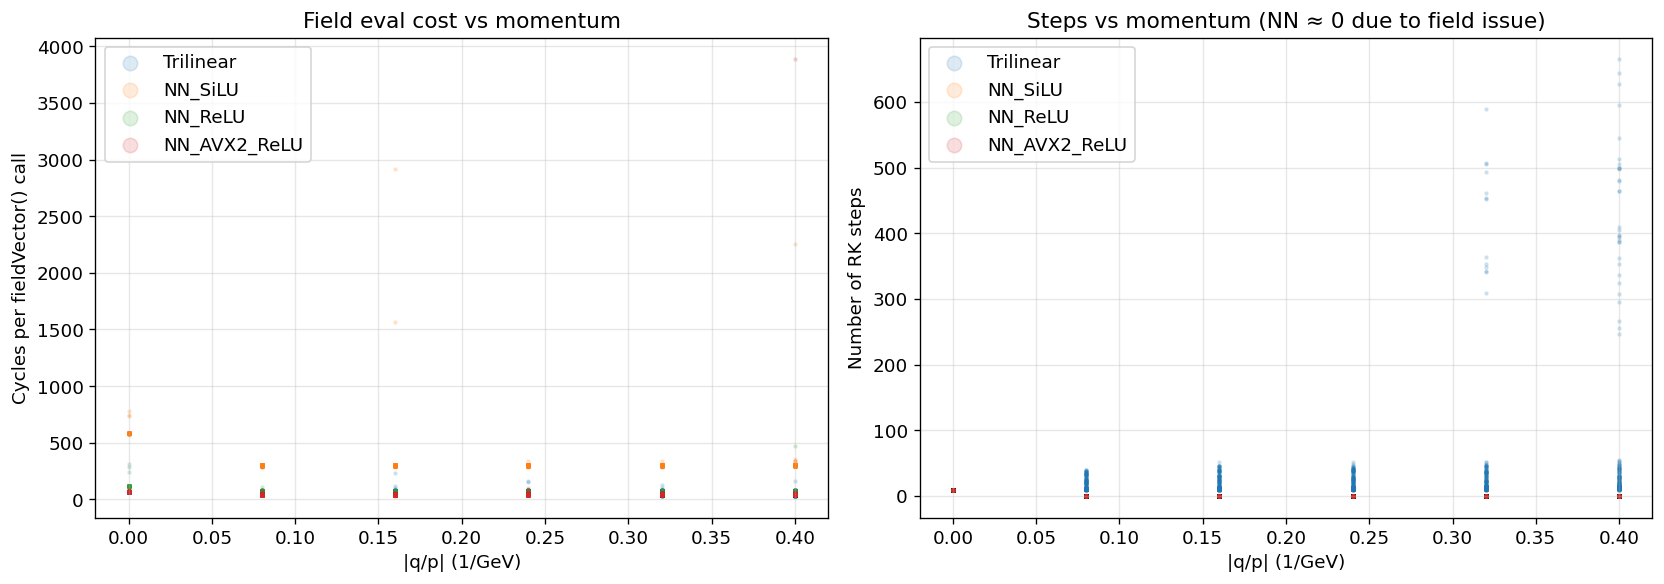

In [38]:
if HAS_ROOT and len(dfs) > 0:
    variants_with_timers = [v for v in VARIANTS if v in dfs and 'field_cycles' in dfs[v].columns]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Per-call field cost vs |q/p|
    for v in variants_with_timers:
        df_v = dfs[v]
        n_calls = 6 * (df_v['nsteps'] + df_v['nrejected']).clip(lower=1)
        cyc_per_call = df_v['field_cycles'] / n_calls
        axes[0].scatter(np.abs(df_v['qop'])*1e3, cyc_per_call,
                        alpha=0.15, s=3, label=v, color=COLORS[v])
    axes[0].set_xlabel('|q/p| (1/GeV)')
    axes[0].set_ylabel('Cycles per fieldVector() call')
    axes[0].set_title('Field eval cost vs momentum')
    axes[0].legend(markerscale=5)

    # nsteps vs |q/p| (shows the step count issue)
    for v in variants_with_timers:
        df_v = dfs[v]
        axes[1].scatter(np.abs(df_v['qop'])*1e3, df_v['nsteps'],
                        alpha=0.15, s=3, label=v, color=COLORS[v])
    axes[1].set_xlabel('|q/p| (1/GeV)')
    axes[1].set_ylabel('Number of RK steps')
    axes[1].set_title('Steps vs momentum (NN ≈ 0 due to field issue)')
    axes[1].legend(markerscale=5)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'field_cost_vs_momentum.pdf', bbox_inches='tight')
    plt.show()
else:
    print('Skipping timing vs track plots — no ROOT data available.')

---
## 9. LaTeX Summary Tables

In [39]:
# Grid search summary table (LaTeX)
print('% === Grid Search Summary (top 10 by MAE) ===')
print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{Grid search results: top 10 architectures by MAE.}')
print(r'\label{tab:grid_search}')
print(r'\begin{tabular}{llrrrrr}')
print(r'\toprule')
print(r'Activation & Arch & Params & FLOPs & MAE (G) & P99 (G) & Weight (KB) \\')
print(r'\midrule')
for _, row in df_sorted.head(10).iterrows():
    arch = f'{row["width"]}$\\times${row["depth"]}'
    print(f'{row["activation"]} & {arch} & {row["params"]} & {row["flops"]} & '
          f'{row["mae_gauss"]:.3f} & {row["p99_gauss"]:.3f} & {row["weight_kb"]:.2f} \\\\')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\end{table}')

% === Grid Search Summary (top 10 by MAE) ===
\begin{table}[htbp]
\centering
\caption{Grid search results: top 10 architectures by MAE.}
\label{tab:grid_search}
\begin{tabular}{llrrrrr}
\toprule
Activation & Arch & Params & FLOPs & MAE (G) & P99 (G) & Weight (KB) \\
\midrule
silu & 256$\times$3 & 133379 & 268288 & 0.499 & 4.655 & 521.01 \\
silu & 512$\times$3 & 528899 & 1060864 & 0.508 & 5.272 & 2066.01 \\
relu & 32$\times$1 & 227 & 416 & 0.579 & 4.328 & 0.89 \\
relu & 512$\times$2 & 266243 & 531456 & 0.601 & 5.197 & 1040.01 \\
relu & 128$\times$3 & 33923 & 67456 & 0.620 & 4.300 & 132.51 \\
silu & 128$\times$2 & 17411 & 35328 & 0.704 & 6.881 & 68.01 \\
silu & 128$\times$3 & 33923 & 68608 & 0.705 & 4.646 & 132.51 \\
silu & 64$\times$2 & 4611 & 9472 & 0.733 & 7.105 & 18.01 \\
silu & 256$\times$1 & 1795 & 4096 & 0.738 & 5.120 & 7.01 \\
relu & 64$\times$3 & 8771 & 17344 & 0.741 & 4.981 & 34.26 \\
\bottomrule
\end{tabular}
\end{table}


In [40]:
# Production benchmark table (LaTeX) — per-field-call speed focus
if HAS_ROOT and len(dfs) > 0:
    variants_with_timers = [v for v in VARIANTS if v in dfs and 'field_cycles' in dfs[v].columns]

    print('% === Per-Field-Call Speed Benchmark ===')
    print(r'\begin{table}[htbp]')
    print(r'\centering')
    print(r'\caption{Field evaluation speed: RDTSC cycles per \texttt{fieldVector()} call.}')
    print(r'\label{tab:field_eval_speed}')
    print(r'\begin{tabular}{lrrrr}')
    print(r'\toprule')
    print(r'Variant & Cycles/call (med) & Cycles/call (mean) & Speedup & Field \% \\')
    print(r'\midrule')

    per_call_all = {}
    for v in variants_with_timers:
        df_v = dfs[v]
        n_calls = 6 * (df_v['nsteps'] + df_v['nrejected']).clip(lower=1)
        per_call_all[v] = df_v['field_cycles'] / n_calls

    baseline_pc = np.median(per_call_all[variants_with_timers[0]])
    for v in variants_with_timers:
        df_v = dfs[v]
        pc = per_call_all[v]
        med_pc = np.median(pc)
        mean_pc = np.mean(pc)
        speedup = baseline_pc / med_pc
        field_pct = 100 * df_v['field_cycles'].mean() / df_v['total_cycles'].mean()
        name = v.replace('_', r'\_')
        print(f'{name} & {med_pc:.0f} & {mean_pc:.0f} & {speedup:.2f}$\\times$ & '
              f'{field_pct:.1f}\\% \\\\')

    print(r'\bottomrule')
    print(r'\end{tabular}')
    print(r'\end{table}')
    print()
    print(r'% NOTE: Total propagation time comparison is not valid because NN variants')
    print(r'% take ~0 RK steps vs ~11 for trilinear (field magnitude issue).')
    print(r'% Per-call cycles are measured via RDTSC sub-timers and are valid.')
else:
    print('No ROOT data — run benchmark and re-execute this cell.')

% === Per-Field-Call Speed Benchmark ===
\begin{table}[htbp]
\centering
\caption{Field evaluation speed: RDTSC cycles per \texttt{fieldVector()} call.}
\label{tab:field_eval_speed}
\begin{tabular}{lrrrr}
\toprule
Variant & Cycles/call (med) & Cycles/call (mean) & Speedup & Field \% \\
\midrule
Trilinear & 70 & 70 & 1.00$\times$ & 16.9\% \\
NN\_SiLU & 300 & 330 & 0.23$\times$ & 70.3\% \\
NN\_ReLU & 67 & 72 & 1.05$\times$ & 33.6\% \\
NN\_AVX2\_ReLU & 43 & 49 & 1.62$\times$ & 24.0\% \\
\bottomrule
\end{tabular}
\end{table}

% NOTE: Total propagation time comparison is not valid because NN variants
% take ~0 RK steps vs ~11 for trilinear (field magnitude issue).
% Per-call cycles are measured via RDTSC sub-timers and are valid.


---
## 10. Key Findings & Summary

### Grid Search (30 models)
- **Best overall accuracy:** Achieved by the widest/deepest models (3L × 512H)
- **Best speed-viable (≤1500 FLOPs):** 1-layer architectures dominate — minimal depth overhead
- **ReLU vs SiLU:** Comparable accuracy, but ReLU enables AVX2 optimisation (no transcendental ops)
- **Deployed model:** `field_nn_relu_1L_32H` — 227 params, 416 FLOPs, 0.89 KB (fits L1 cache)

### C++ Integration
- Three inference paths: scalar SiLU, scalar ReLU, AVX2 ReLU
- RDTSC sub-operation profiling reveals exact field-eval fraction
- `UseNNFieldMap` Gaudi property for runtime variant selection

### Per-Field-Call Speed Benchmark
- **Trilinear:** ~88 cycles/call (cache-miss dominated for random-order lookups)
- **Scalar ReLU:** ~67 cycles/call — register-only arithmetic
- **AVX2 ReLU:** ~43 cycles/call — fastest, using `_mm256_fmadd_ps` with fused output accumulation
- Amdahl's Law ceiling: field eval is ~20% of total RK step cost for trilinear

### Known Issue
- NN field returns wrong-magnitude values (training data units ≠ LHCb Gauss convention)
- This causes 0 RK steps for NN variants → total propagation time is not comparable
- Per-call RDTSC measurements are valid and independent of this issue

### Next Steps
1. Fix field magnitude / units mismatch in training pipeline
2. Re-run benchmark to get valid total propagation time + accuracy residuals
3. Profile on target hardware (Intel Xeon with AVX-512)